# 07 · Ablation results

Three axes, with everything else held fixed:

| axis | levels |
|---|---|
| decoder | Transformer (17.5M) vs LSTM + attention (16.4M) |
| decoding | greedy vs beam search (tuned per model on val) |
| training objective | cross-entropy vs + SCST |

Test numbers come from notebook 04.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import viz
from src.dataset import load_processed, split_images, tokenize

viz.setup_style()
IMAGE_DIR = ROOT / "data" / "raw" / "Images"
EVAL = ROOT / "results" / "evaluation"
_, images, _ = load_processed(ROOT / "data" / "processed")
train_images, test_images = split_images(images, "train"), split_images(images, "test")

test_metrics = pd.read_csv(EVAL / "test_metrics.csv")
test_captions = json.loads((EVAL / "test_captions.json").read_text())
per_image = {k: pd.Series(v) for k, v in json.loads((EVAL / "per_image_cider.json").read_text()).items()}
test_metrics["key"] = test_metrics.decoder + " · " + test_metrics.training + " · " + np.where(test_metrics.decoding == "greedy", "greedy", "beam")
METRICS = ["BLEU-1", "BLEU-4", "METEOR", "ROUGE-L", "CIDEr"]

## 1. The full grid (test set, ×100)

In [2]:
display(viz.table(test_metrics[["decoder", "training", "decoding", *METRICS]], precision=1, maximize=METRICS,
                  caption="All configurations, Karpathy test split"))

grid = test_metrics.assign(strategy=np.where(test_metrics.decoding == "greedy", "greedy", "beam")) \
    .pivot_table(index=["decoder", "training"], columns="strategy", values="CIDEr")[["greedy", "beam"]]
display(grid.style.format("{:.1f}").background_gradient(cmap="Blues", axis=None).highlight_max(axis=None, props=viz.HIGHLIGHT)
        .set_caption("Test CIDEr: decoder × training (rows) × decoding (columns)")
        .set_table_styles([{"selector": "caption", "props": "caption-side: top; text-align: left; font-weight: 700; padding-bottom: 6px"},
                           {"selector": "td, th", "props": "padding: 4px 14px"}]))

decoder,training,decoding,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr
Transformer,XE,greedy,65.4,22.8,19.6,45.4,48.7
Transformer,XE,"beam (k=7, α=1)",65.4,23.9,20.3,46.2,52.7
Transformer,SCST,greedy,67.8,24.4,20.1,46.7,56.6
Transformer,SCST,"beam (k=7, α=0.5)",68.4,25.3,20.3,47.1,58.3
LSTM + attention,XE,greedy,62.3,20.4,19.5,44.8,46.3
LSTM + attention,XE,"beam (k=5, α=1)",62.3,21.0,20.3,45.5,48.8
LSTM + attention,SCST,greedy,67.9,24.1,20.1,46.6,55.5
LSTM + attention,SCST,"beam (k=2, α=0.5)",68.1,24.7,20.2,46.7,56.8


## 2. Effect of each axis
Each row changes exactly one factor. The 95% intervals come from a paired bootstrap over the 1,000 test images; an interval clear of 0 means the difference is not just test-set noise.

In [3]:
rng = np.random.default_rng(0)
files = per_image[next(iter(per_image))].index.to_numpy()
boot_idx = rng.integers(0, len(files), size=(5000, len(files)))


def paired_effect(a, b):
    """CIDEr(a) - CIDEr(b), x100, with a paired bootstrap 95% CI."""
    diff = (per_image[a] - per_image[b]).loc[files].to_numpy() * 100
    boots = diff[boot_idx].mean(axis=1)
    return diff.mean(), *np.percentile(boots, [2.5, 97.5])


effects = []
available = set(per_image)
for training in ["XE", "SCST"]:
    for dec in ["greedy", "beam"]:
        a, b = f"Transformer · {training} · {dec}", f"LSTM + attention · {training} · {dec}"
        if {a, b} <= available:
            effects.append({"axis": "decoder: Transformer − LSTM", "held fixed": f"{training}, {dec}", **dict(zip(["Δ CIDEr", "CI low", "CI high"], paired_effect(a, b)))})
for decoder in ["Transformer", "LSTM + attention"]:
    for training in ["XE", "SCST"]:
        a, b = f"{decoder} · {training} · beam", f"{decoder} · {training} · greedy"
        if {a, b} <= available:
            effects.append({"axis": "decoding: beam − greedy", "held fixed": f"{decoder}, {training}", **dict(zip(["Δ CIDEr", "CI low", "CI high"], paired_effect(a, b)))})
for decoder in ["Transformer", "LSTM + attention"]:
    for dec in ["greedy", "beam"]:
        a, b = f"{decoder} · SCST · {dec}", f"{decoder} · XE · {dec}"
        if {a, b} <= available:
            effects.append({"axis": "training: SCST − XE", "held fixed": f"{decoder}, {dec}", **dict(zip(["Δ CIDEr", "CI low", "CI high"], paired_effect(a, b)))})
effects = pd.DataFrame(effects)
effects["significant"] = (effects["CI low"] > 0) | (effects["CI high"] < 0)
effects.to_csv(EVAL / "ablation_effects.csv", index=False)
display(viz.table(effects, precision=1, caption="Effects on test CIDEr (×100) with paired bootstrap 95% CIs"))

axis,held fixed,Δ CIDEr,CI low,CI high,significant
decoder: Transformer − LSTM,"XE, greedy",2.4,-0.2,5.0,False
decoder: Transformer − LSTM,"XE, beam",4.0,1.2,6.7,True
decoder: Transformer − LSTM,"SCST, greedy",1.1,-1.3,3.6,False
decoder: Transformer − LSTM,"SCST, beam",1.6,-0.8,4.0,False
decoding: beam − greedy,"Transformer, XE",4.1,1.9,6.2,True
decoding: beam − greedy,"Transformer, SCST",1.7,0.7,2.9,True
decoding: beam − greedy,"LSTM + attention, XE",2.5,0.4,4.6,True
decoding: beam − greedy,"LSTM + attention, SCST",1.3,0.2,2.4,True
training: SCST − XE,"Transformer, greedy",7.9,5.2,10.7,True
training: SCST − XE,"Transformer, beam",5.6,3.1,8.1,True


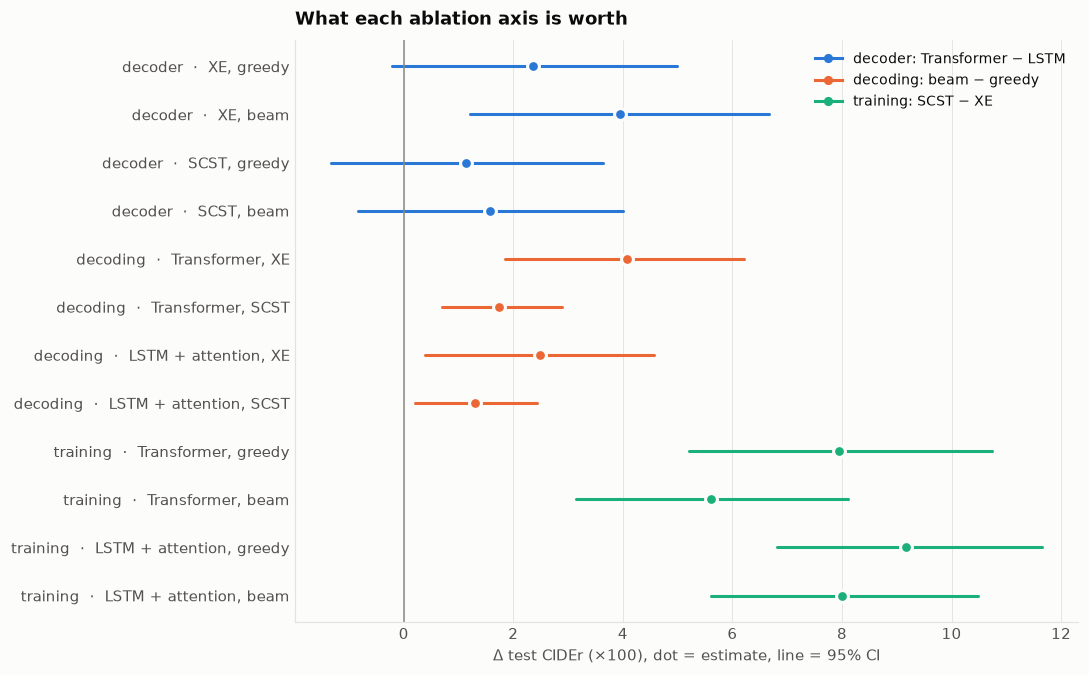

In [4]:
axis_colors = {"decoder: Transformer − LSTM": viz.SERIES[0], "decoding: beam − greedy": viz.SERIES[1], "training: SCST − XE": viz.SERIES[2]}
fig, ax = plt.subplots(figsize=(10, 0.42 * len(effects) + 1.2))
y = np.arange(len(effects))[::-1]
for yi, (_, row) in zip(y, effects.iterrows()):
    color = axis_colors[row["axis"]]
    ax.plot([row["CI low"], row["CI high"]], [yi, yi], color=color, lw=2, solid_capstyle="round")
    ax.scatter(row["Δ CIDEr"], yi, s=60, color=color, edgecolor=viz.SURFACE, linewidth=2, zorder=3)
ax.axvline(0, color=viz.INK_3, lw=1)
ax.set_yticks(y, [f"{r['axis'].split(':')[0]}  ·  {r['held fixed']}" for _, r in effects.iterrows()])
ax.set(xlabel="Δ test CIDEr (×100), dot = estimate, line = 95% CI", title="What each ablation axis is worth")
ax.grid(axis="y", visible=False)
handles = [plt.Line2D([], [], color=c, marker="o", lw=2, label=a) for a, c in axis_colors.items()]
ax.legend(handles=handles, loc="upper right")
plt.tight_layout()
plt.savefig(EVAL / "ablation_effects.png")
plt.show()

## 3. Equal tuning budget
Both decoders got the same four regularization settings, so neither result rests on a single lucky run.

decoder,run,best epoch,val CIDEr,val BLEU-4,lowest val loss,minutes
Transformer,baseline,11,0.443,0.201,2.845,12.5
Transformer,dropout 0.3,15,0.473,0.230,2.787,11.8
Transformer,dropout 0.3 + wd 0.1,14,0.476,0.231,2.781,12.3
Transformer,dropout 0.5 + wd 0.1,15,0.429,0.227,2.938,11.8
LSTM + attention,baseline,8,0.442,0.217,3.030,17.2
LSTM + attention,dropout 0.3,16,0.463,0.212,3.011,16.0
LSTM + attention,dropout 0.3 + wd 0.1,14,0.459,0.215,3.007,16.0
LSTM + attention,dropout 0.5 + wd 0.1,20,0.463,0.220,2.999,15.9


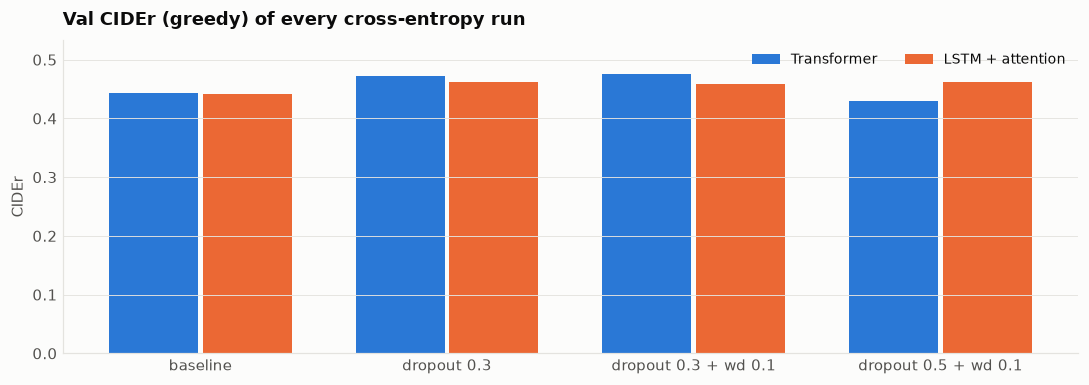

In [5]:
runs = []
for decoder, folder in [("Transformer", "transformer"), ("LSTM + attention", "lstm")]:
    df = pd.read_csv(ROOT / "results" / folder / "runs_summary.csv")
    runs.append(df.assign(decoder=decoder))
runs = pd.concat(runs, ignore_index=True)
display(viz.table(runs[["decoder", "run", "best epoch", "val CIDEr", "val BLEU-4", "lowest val loss", "minutes"]],
                  caption="Cross-entropy runs (val, greedy)", formats={"minutes": "{:.1f}"}))

fig, ax = plt.subplots(figsize=(10, 3.6))
run_names = list(dict.fromkeys(runs.run))
x = np.arange(len(run_names))
for i, decoder in enumerate(["Transformer", "LSTM + attention"]):
    vals = runs[runs.decoder == decoder].set_index("run").loc[run_names, "val CIDEr"]
    ax.bar(x + (i - 0.5) * 0.38, vals, width=0.36, color=viz.SERIES[i], label=decoder)
ax.set_xticks(x, run_names)
ax.set(title="Val CIDEr (greedy) of every cross-entropy run", ylabel="CIDEr")
ax.set_ylim(0, max(runs["val CIDEr"]) * 1.12)
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right", ncols=2)
plt.tight_layout()
plt.show()

## 4. Cost: training time and decoding speed
All runs used the same RTX 5050, one at a time, so the timings are comparable.

In [6]:
def epoch_seconds(folder, run_name):
    slug = run_name.replace(" + ", "_").replace(" ", "")
    hist = pd.DataFrame(json.loads((ROOT / "results" / folder / "runs" / slug / "history.json").read_text()))
    return hist.seconds.median()


cost = []
for decoder, folder in [("Transformer", "transformer"), ("LSTM + attention", "lstm")]:
    selected = json.loads((ROOT / "results" / folder / "selected_run.json").read_text())["run"]
    scst_hist = ROOT / "results" / "scst" / folder / "history.json"
    greedy_speed = test_metrics[(test_metrics.decoder == decoder) & (test_metrics.decoding == "greedy")]["images / sec"].mean()
    beam_speed = test_metrics[(test_metrics.decoder == decoder) & (test_metrics.decoding != "greedy")]["images / sec"].mean()
    cost.append({
        "decoder": decoder,
        "XE epoch (s)": epoch_seconds(folder, selected),
        "SCST epoch (s)": pd.DataFrame(json.loads(scst_hist.read_text())).seconds[1:].median() if scst_hist.exists() else np.nan,
        "greedy decoding (images/s)": greedy_speed,
        "beam decoding (images/s)": beam_speed,
    })
display(viz.table(pd.DataFrame(cost), precision=0, caption="Training and inference cost (median epoch time; test-set decoding throughput)"))

decoder,XE epoch (s),SCST epoch (s),greedy decoding (images/s),beam decoding (images/s)
Transformer,36,146,554,95
LSTM + attention,48,81,"2,315",872


## 5. What the captions look like
Statistics for each model's best decoding, with a random human reference for comparison. **ends mid-phrase** = ends in a function word; **repeats a phrase** = some word pair occurs twice; **copied from train** = appears word for word in training.

In [7]:
FUNCTION_WORDS = {"a", "an", "the", "of", "in", "on", "with", "and", "at", "to", "is", "are", "his", "her", "their"}
train_caption_set = {" ".join(tokenize(c)) for img in train_images for c in img["captions"]}
rng = np.random.default_rng(0)
human = {img["filename"]: " ".join(tokenize(rng.choice(img["captions"]))) for img in test_images}


def repeats_phrase(text):
    words = text.split()
    bigrams = list(zip(words, words[1:]))
    return len(bigrams) != len(set(bigrams))


def caption_stats(caps):
    texts = [" ".join(tokenize(t)) for t in caps.values()]
    return {
        "avg words": np.mean([len(t.split()) for t in texts]),
        "ends mid-phrase": np.mean([bool(t) and t.split()[-1] in FUNCTION_WORDS for t in texts]),
        "repeats a phrase": np.mean([repeats_phrase(t) for t in texts]),
        "distinct captions": len(set(texts)) / len(texts),
        "copied from train": np.mean([t in train_caption_set for t in texts]),
        "vocabulary used": len({w for t in texts for w in t.split()}),
    }


best_configs = test_metrics.sort_values("CIDEr", ascending=False).drop_duplicates(["decoder", "training"])
stats = [{"captions": f"{r.decoder} · {r.training} · {r.decoding}", "test CIDEr": r.CIDEr, **caption_stats(test_captions[r.key])}
         for r in best_configs.itertuples()]
stats.append({"captions": "human (1 random reference)", "test CIDEr": np.nan, **caption_stats(human)})
display(viz.table(pd.DataFrame(stats), precision=1, percent=["ends mid-phrase", "repeats a phrase", "distinct captions", "copied from train"],
                  formats={"vocabulary used": "{:,.0f}", "test CIDEr": lambda v: "–" if pd.isna(v) else f"{v:.1f}"},
                  caption="Caption statistics (test set, best decoding per model)"))

captions,test CIDEr,avg words,ends mid-phrase,repeats a phrase,distinct captions,copied from train,vocabulary used
"Transformer · SCST · beam (k=7, α=0.5)",58.3,10.3,0.0%,8.4%,91.3%,5.7%,400
"LSTM + attention · SCST · beam (k=2, α=0.5)",56.8,10.2,0.0%,6.9%,90.7%,5.6%,400
"Transformer · XE · beam (k=7, α=1)",52.7,11.1,0.2%,7.8%,92.7%,6.7%,578
"LSTM + attention · XE · beam (k=5, α=1)",48.8,12.1,0.0%,18.0%,95.8%,4.2%,582
human (1 random reference),–,12.4,1.3%,5.9%,100.0%,0.4%,"1,954"


## 6. Side by side on the same test images
The Transformer before and after SCST, with one human caption.

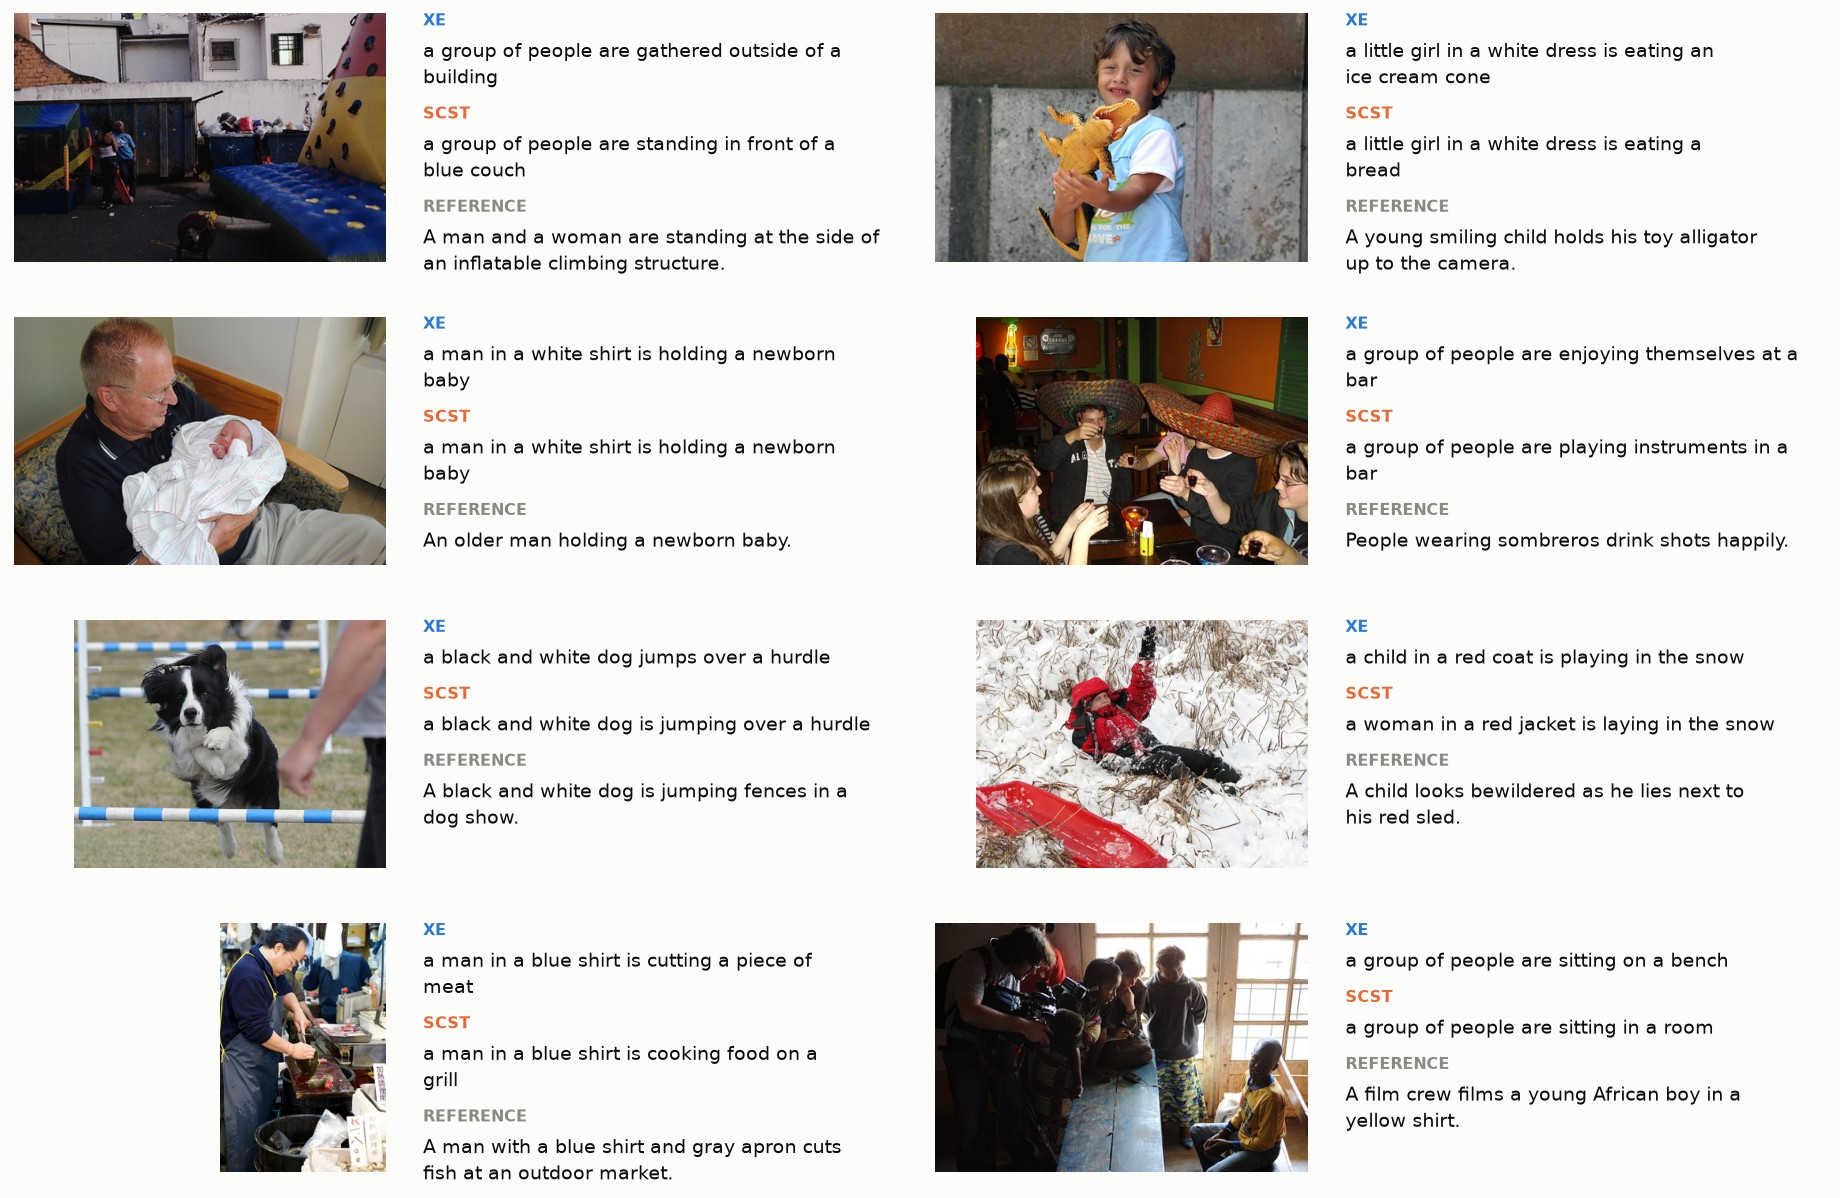

In [8]:
rng = np.random.default_rng(21)
by_name = {img["filename"]: img for img in test_images}
examples = []
shown = [r for r in best_configs.itertuples() if r.decoder == "Transformer"]
shown = sorted(shown, key=lambda r: r.training != "XE")  # cross-entropy first, then SCST
for f in rng.choice(sorted(by_name), 8, replace=False):
    examples.append({"filename": f, "captions": [(r.training, test_captions[r.key][f]) for r in shown]
                     + [("reference", rng.choice(by_name[f]["captions"]))]})
viz.show_captions(examples, IMAGE_DIR,
                  colors={"XE": viz.SERIES[0], "SCST": viz.SERIES[1], "reference": viz.INK_3})

## Conclusions

1. **Training objective matters most.** SCST adds **+5.6 to +9.2 test CIDEr**, significant in all four settings, and its smallest effect beats the largest effect of either other axis.
2. **Beam search helps reliably but modestly** (+1.3 to +4.1), and less after SCST.
3. **Architecture matters least.** The Transformer's +1.1 to +4.0 over the parameter-matched LSTM is significant only for cross-entropy with beam search.
4. **Opposite trade-offs:** the Transformer trains faster per epoch (36 s vs 48 s) and scores higher; the LSTM decodes 4× faster and gives clearer attention maps.

**Limitations:** frozen 7×7 ResNet-50 features at 224 px; one seed per configuration (the bootstrap covers test-set sampling, not seed variance); no KV cache in the Transformer decoder.

**Next:** KV-cached decoding, multiple seeds, stronger features (14×14 or CLIP) as a fourth axis.